# 🛒 Wholesale Customers — Segmentación con KMeans
## Machine Learning III · Análisis no supervisado para segmentación de clientes

---

Este notebook aplica clustering KMeans sobre el dataset *Wholesale customers* (UCI)  
para identificar grupos de clientes con patrones de compra similares.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y exploración inicial (EDA) |
| 2️⃣ | Limpieza y preprocesamiento — detección de nulos, escalado con `StandardScaler` |
| 3️⃣ | Método del codo — selección del número óptimo de clusters |
| 4️⃣ | Entrenamiento de KMeans |
| 5️⃣ | Visualización con PCA y t-SNE |
| 6️⃣ | Análisis de clusters — boxplots y perfiles de grupo |
| 7️⃣ | Conclusiones |

> **Dataset:** `dataset.csv` — 440 clientes · 8 columnas  
> **Objetivo:** agrupar clientes según gasto anual en 6 categorías de productos  
> **Ruta:** `/workspace/dataset.csv`


---
## 0. Importación de librerías y configuración


In [18]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

INPUT_PATH   = "workspace/dataset.csv"
RANDOM_STATE = 42

# ── Rango de k para el método del codo ───────────────────────────────────
# Parametrizar K_MIN / K_MAX permite reducir el coste en datasets grandes
# sin tocar el código del bucle. Con 440 filas, [2, 10] es rápido.
K_MIN = 2
K_MAX = 10

# ── Flags de ejecución ───────────────────────────────────────────────────
RUN_TSNE      = True   # False → omite t-SNE (útil en entornos con pocos recursos)
TSNE_MAX_ITER = 1000   # Reducir (p.ej. 300) para ejecuciones más rápidas
                       # a costa de una convergencia menos precisa

print("✅ Librerías y configuración cargadas.")
print(f"   K_MIN={K_MIN}  K_MAX={K_MAX}  |  RUN_TSNE={RUN_TSNE}  "
      f"TSNE_MAX_ITER={TSNE_MAX_ITER}  |  RANDOM_STATE={RANDOM_STATE}")
print(f"📂 Ruta del dataset: {INPUT_PATH}")


✅ Librerías y configuración cargadas.
   K_MIN=2  K_MAX=10  |  RUN_TSNE=True  TSNE_MAX_ITER=1000  |  RANDOM_STATE=42
📂 Ruta del dataset: workspace/dataset.csv


---
## 1. Carga y Exploración de Datos (EDA)

### 1.1 Carga del dataset


In [19]:
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"\n❌ No se encontró: {INPUT_PATH}\n"
        "   Coloca dataset.csv en /workspace/ antes de ejecutar."
    )

df = pd.read_csv(INPUT_PATH)
print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n📋 Columnas:")
for col in df.columns:
    print(f"  · {col:20s}  dtype={df[col].dtype}")


📐 Dimensiones: 440 filas × 8 columnas

📋 Columnas:
  · Channel               dtype=int64
  · Region                dtype=int64
  · Fresh                 dtype=int64
  · Milk                  dtype=int64
  · Grocery               dtype=int64
  · Frozen                dtype=int64
  · Detergents_Paper      dtype=int64
  · Delicassen            dtype=int64


### 1.2 Primeras filas

In [20]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### 1.3 Estadísticas descriptivas

In [21]:
desc = df.describe().round(2)
print(desc.to_string())


       Channel  Region      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
count   440.00  440.00     440.00    440.00    440.00    440.00            440.00      440.00
mean      1.32    2.54   12000.30   5796.27   7951.28   3071.93           2881.49     1524.87
std       0.47    0.77   12647.33   7380.38   9503.16   4854.67           4767.85     2820.11
min       1.00    1.00       3.00     55.00      3.00     25.00              3.00        3.00
25%       1.00    2.00    3127.75   1533.00   2153.00    742.25            256.75      408.25
50%       1.00    3.00    8504.00   3627.00   4755.50   1526.00            816.50      965.50
75%       2.00    3.00   16933.75   7190.25  10655.75   3554.25           3922.00     1820.25
max       2.00    3.00  112151.00  73498.00  92780.00  60869.00          40827.00    47943.00


### 1.4 Distribución de las variables de gasto

Las 6 columnas de gasto (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`)  
presentan alta asimetría positiva — típico en datos de gasto empresarial.


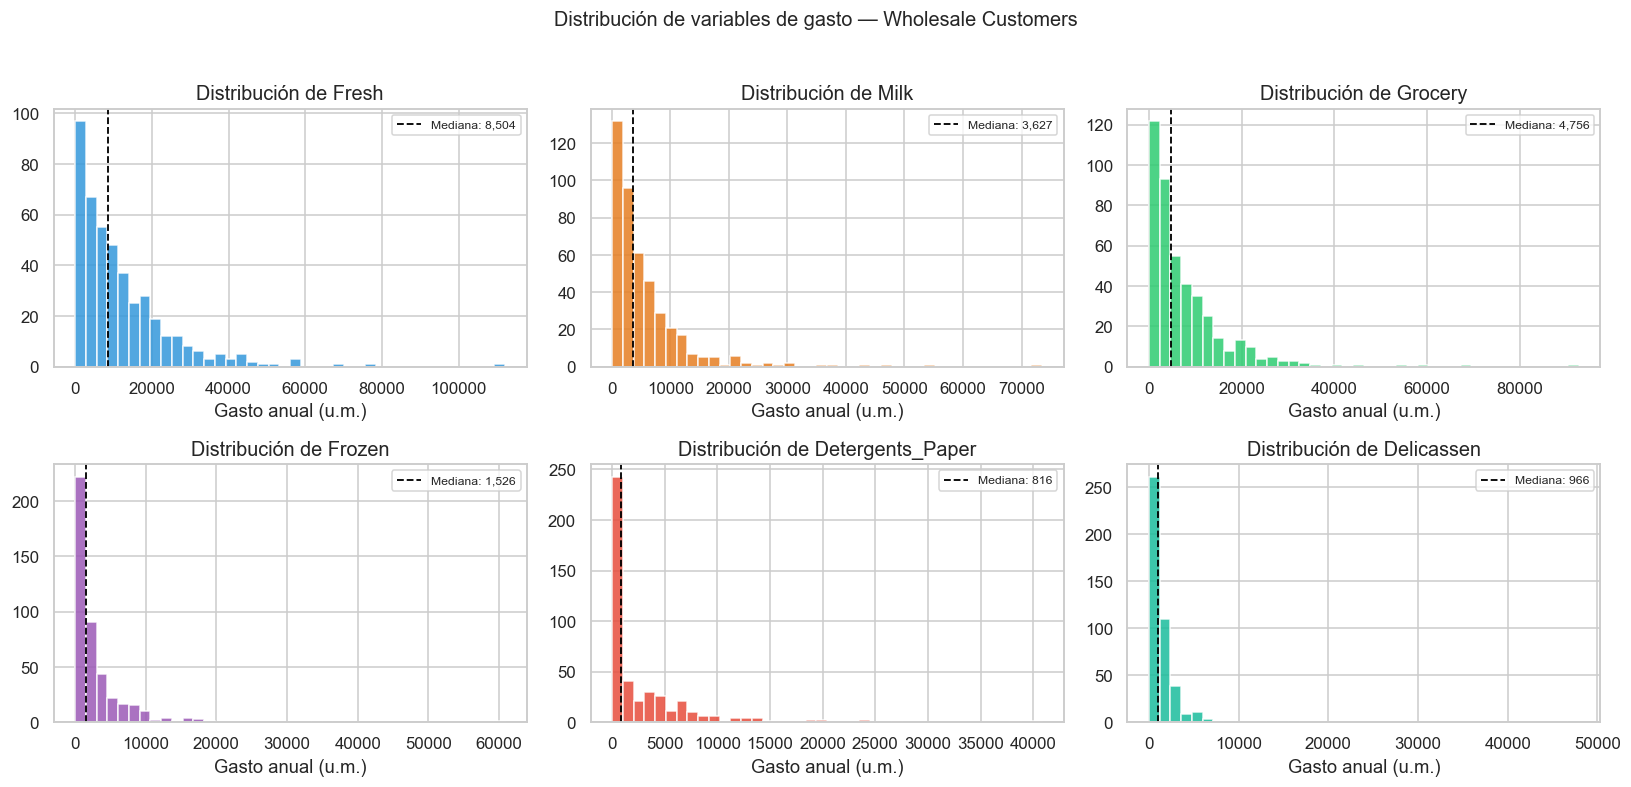

📊 Asimetría (skew) por variable:
  · Fresh               : 2.56
  · Milk                : 4.05
  · Grocery             : 3.59
  · Frozen              : 5.91
  · Detergents_Paper    : 3.63
  · Delicassen          : 11.15


In [22]:
FEATURES = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
colores = ["#3498db","#e67e22","#2ecc71","#9b59b6","#e74c3c","#1abc9c"]

for ax, col, color in zip(axes, FEATURES, colores):
    ax.hist(df[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].median(), color="black", linestyle="--", linewidth=1.2,
               label=f"Mediana: {df[col].median():,.0f}")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("Gasto anual (u.m.)")
    ax.legend(fontsize=8)

plt.suptitle("Distribución de variables de gasto — Wholesale Customers", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("📊 Asimetría (skew) por variable:")
for col in FEATURES:
    print(f"  · {col:20s}: {df[col].skew():.2f}")


---
## 2. Limpieza y Preprocesamiento

### 2.1 Detección de valores nulos e inconsistencias


In [23]:
# ── Valores nulos ─────────────────────────────────────────────────────────────
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df  = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct})
print("🔍 Valores nulos por columna:")
print(nulos_df.to_string())
print(f"\n  Total: {nulos.sum()} nulos "
      f"({nulos.sum()/df.size*100:.2f}% del total de celdas)")
print(f"  {'✅ Sin valores nulos — no se requiere imputación.' if nulos.sum() == 0 else '⚠️ Se requiere tratamiento.'}")

# ── Duplicados ────────────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f"\n🔍 Filas duplicadas: {n_dup} "
      f"({n_dup/len(df)*100:.2f}% del total de filas) "
      f"{'✅' if n_dup == 0 else '→ se eliminarán'}")
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   Filas tras eliminar duplicados: {len(df)}")

# ── Valores negativos (imposibles en gasto) ───────────────────────────────────
print("\n🔍 Valores negativos por columna de gasto:")
for col in FEATURES:
    n_neg = (df[col] < 0).sum()
    print(f"  · {col:20s}: {n_neg}")

# ── Coherencia básica: filas con todo cero en las variables de gasto ─────
# Una fila con todo-cero sería anómala: significaría un cliente sin
# ningún gasto registrado, lo que podría ser un error de carga o
# un registro vacío que distorsionaría los centroides de KMeans.
mask_allzero = (df[FEATURES] == 0).all(axis=1)
n_allzero    = mask_allzero.sum()
print(f"\n🔍 Filas con todo-cero en las 6 variables de gasto: {n_allzero} "
      f"{'✅' if n_allzero == 0 else '⚠️ — revisar y eliminar antes de clustering'}")
if n_allzero > 0:
    print("   Índices afectados:", df.index[mask_allzero].tolist())
    df = df[~mask_allzero].reset_index(drop=True)
    print(f"   Filas tras eliminar todo-cero: {len(df)}")

# ── Coherencia adicional: filas con gasto total = 0 en al menos una variable
# (valores cero en columnas individuales pueden ser válidos — p.ej. un cliente
# que no compra productos frescos — pero se informa para trazabilidad)
for col in FEATURES:
    n_zero = (df[col] == 0).sum()
    if n_zero > 0:
        pct = n_zero / len(df) * 100
        print(f"  · {col:20s}: {n_zero} valores cero ({pct:.1f}%) "
              f"— posiblemente válidos (cliente no compra esa categoría)")


🔍 Valores nulos por columna:
                  Nulos  Porcentaje (%)
Channel               0             0.0
Region                0             0.0
Fresh                 0             0.0
Milk                  0             0.0
Grocery               0             0.0
Frozen                0             0.0
Detergents_Paper      0             0.0
Delicassen            0             0.0

  Total: 0 nulos (0.00% del total de celdas)
  ✅ Sin valores nulos — no se requiere imputación.

🔍 Filas duplicadas: 0 (0.00% del total de filas) ✅

🔍 Valores negativos por columna de gasto:
  · Fresh               : 0
  · Milk                : 0
  · Grocery             : 0
  · Frozen              : 0
  · Detergents_Paper    : 0
  · Delicassen          : 0

🔍 Filas con todo-cero en las 6 variables de gasto: 0 ✅


### 2.2 Detección de outliers extremos — método IQR

Los datos de gasto empresarial suelen presentar valores extremos legítimos  
(un gran distribuidor puede gastar 10× la media). Se identifican con el método IQR  
**sin eliminarlos**, ya que pueden ser segmentos de clientes relevantes para el clustering.

> Los outliers en KMeans pueden crear clusters propios o sesgar los centroides.  
> Se documentan aquí para tener conciencia de su impacto en el modelo.


In [24]:
print("🔍 Outliers extremos por variable (método IQR, factor=1.5):\n")
print(f"  {'Variable':<22}  {'Q1':>10}  {'Q3':>10}  {'IQR':>10}  "
      f"{'Lím. inf.':>12}  {'Lím. sup.':>12}  {'N outliers':>11}  {'% total':>8}")
print("  " + "─" * 100)

outlier_info = {}
for col in FEATURES:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    mask    = (df[col] < lim_inf) | (df[col] > lim_sup)
    n_out   = mask.sum()
    pct_out = n_out / len(df) * 100
    outlier_info[col] = {"n": n_out, "pct": pct_out,
                          "lim_inf": lim_inf, "lim_sup": lim_sup}
    flag = "⚠️" if pct_out > 5 else ("🔶" if n_out > 0 else "✅")
    print(f"  {flag} {col:<20}  {Q1:>10,.0f}  {Q3:>10,.0f}  {IQR:>10,.0f}  "
          f"{lim_inf:>12,.0f}  {lim_sup:>12,.0f}  {n_out:>11d}  {pct_out:>7.1f}%")

# ── Comparativa: mantener vs recortar outliers ────────────────────────────
mask_all_out = pd.Series(False, index=df.index)
for col in FEATURES:
    li = outlier_info[col]["lim_inf"]; ls = outlier_info[col]["lim_sup"]
    mask_all_out |= (df[col] < li) | (df[col] > ls)

n_afectados   = mask_all_out.sum()
n_conservados = len(df) - n_afectados

print(f"\n📊 Impacto de recortar outliers IQR (al menos un outlier en cualquier variable):")
print(f"  · Registros con al menos 1 outlier: {n_afectados:>4d}  ({n_afectados/len(df)*100:.1f}%)")
print(f"  · Registros que se conservarían:    {n_conservados:>4d}  ({n_conservados/len(df)*100:.1f}%)")
print(f"\n  Comparativa mantener vs recortar:")
print(f"  {'Opción':<30}  {'N filas':>8}  {'Comentario'}")
print("  " + "─" * 70)
print(f"  {'Mantener (decisión actual)':<30}  {len(df):>8}  Sin pérdida · outliers = segmentos válidos")
print(f"  {'Recortar (si se eligiese)':<30}  {n_conservados:>8}  -{n_afectados} filas · "
      f"outliers podrían sesgar centroides")
print()
print("  💡 Decisión: se conservan todos los outliers.")
print("     En datos de wholesale, valores extremos representan")
print("     grandes distribuidores o cadenas — segmentos válidos para clustering.")


🔍 Outliers extremos por variable (método IQR, factor=1.5):

  Variable                        Q1          Q3         IQR     Lím. inf.     Lím. sup.   N outliers   % total
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  🔶 Fresh                      3,128      16,934      13,806       -17,581        37,643           20      4.5%
  ⚠️ Milk                       1,533       7,190       5,657        -6,953        15,676           28      6.4%
  ⚠️ Grocery                    2,153      10,656       8,503       -10,601        23,410           24      5.5%
  ⚠️ Frozen                       742       3,554       2,812        -3,476         7,772           43      9.8%
  ⚠️ Detergents_Paper             257       3,922       3,665        -5,241         9,420           30      6.8%
  ⚠️ Delicassen                   408       1,820       1,412        -1,710         3,938           27      6.1%

📊 Impacto de recortar outliers IQR (al menos un

### 2.2 Selección de features y escalado

Excluimos `Channel` y `Region` — son variables categóricas que identifican el canal de distribución  
y la región, no métricas de gasto, por lo que no deben influir en la agrupación por comportamiento de compra.

`StandardScaler` centra cada variable en media=0 y σ=1, obligatorio para KMeans  
que minimiza distancias euclídeas y es sensible a la magnitud de las variables.


In [25]:
# Solo las 6 variables de gasto
X = df[FEATURES].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── DataFrame escalado con nombres de columna (facilita inspección) ──────
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=X.index)

print(f"✅ StandardScaler aplicado a {len(FEATURES)} columnas:")
print(f"   {'Columna':<22}  {'Media original':>16}  {'Std original':>14}  "
      f"{'Media escalada':>16}  {'Std escalada':>13}")
print("   " + "─" * 88)
for i, col in enumerate(FEATURES):
    print(f"   {col:<22}  {df[col].mean():>16,.1f}  {df[col].std():>14,.1f}  "
          f"{X_scaled[:,i].mean():>16.3f}  {X_scaled[:,i].std():>13.3f}")

print(f"\n  X_scaled_df shape: {X_scaled_df.shape}  — DataFrame con nombres de columna")
print(f"  Primeras filas del DataFrame escalado:")
print(X_scaled_df.head(3).round(4).to_string())

# ── Nota sobre MiniBatchKMeans ────────────────────────────────────────────
print()
print("  ℹ️  Nota de escalabilidad:")
print("     Con 440 filas, KMeans estándar es perfectamente adecuado.")
print("     Para datasets mucho más grandes (>100 000 filas), considerar:")
print("       MiniBatchKMeans(n_clusters=k, batch_size=1024, random_state=42)")
print("     MiniBatchKMeans procesa mini-lotes en lugar del dataset completo,")
print("     reduciendo el tiempo de cómputo a costa de una ligera pérdida de precisión.")


✅ StandardScaler aplicado a 6 columnas:
   Columna                   Media original    Std original    Media escalada   Std escalada
   ────────────────────────────────────────────────────────────────────────────────────────
   Fresh                           12,000.3        12,647.3            -0.000          1.000
   Milk                             5,796.3         7,380.4             0.000          1.000
   Grocery                          7,951.3         9,503.2            -0.000          1.000
   Frozen                           3,071.9         4,854.7             0.000          1.000
   Detergents_Paper                 2,881.5         4,767.9             0.000          1.000
   Delicassen                       1,524.9         2,820.1            -0.000          1.000

  X_scaled_df shape: (440, 6)  — DataFrame con nombres de columna
  Primeras filas del DataFrame escalado:
    Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  0.0529  0.5236  -0.0411 -0.5894          

---
## 3. Método del Codo — Número Óptimo de Clusters

Evaluamos KMeans con k ∈ [2, 10] y registramos la **inercia** (suma de cuadrados  
intra-cluster) y el **Silhouette Score** para elegir el k óptimo.


  k= 2  inercia=   1,956.1  silhouette=0.5472
  k= 3  inercia=   1,608.4  silhouette=0.5483
  k= 4  inercia=   1,317.8  silhouette=0.3485
  k= 5  inercia=   1,058.8  silhouette=0.3690
  k= 6  inercia=     915.7  silhouette=0.3782
  k= 7  inercia=     825.4  silhouette=0.3343
  k= 8  inercia=     737.4  silhouette=0.3201
  k= 9  inercia=     661.4  silhouette=0.3090
  k=10  inercia=     605.9  silhouette=0.3112


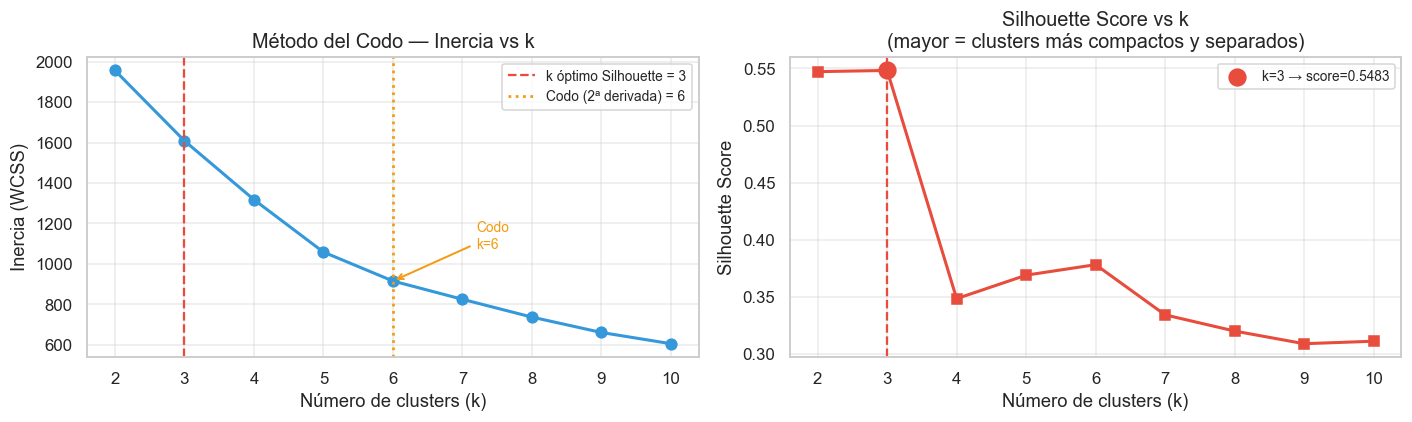


🏆 k óptimo (Silhouette):    k=3  (score=0.5483)
📐 Codo (2ª derivada inercia): k=6
  ⚠️ Criterios difieren — se usará k=3 (Silhouette más fiable).
   → K_OPTIMO = 3


In [26]:
K_RANGE = range(K_MIN, K_MAX + 1)   # parametrizado con K_MIN / K_MAX (celda 0)

inercias          = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"  k={k:2d}  inercia={km.inertia_:>10,.1f}  "
          f"silhouette={silhouette_scores[-1]:.4f}")

k_opt_sil = list(K_RANGE)[silhouette_scores.index(max(silhouette_scores))]

# ── Detectar punto de inflexión (codo) por segunda derivada ──────────────
# La segunda derivada de la inercia es máxima en el punto donde la curva
# 'dobla' más — ese es el codo matemático.
inercias_arr   = np.array(inercias)
segunda_deriv  = np.diff(inercias_arr, n=2)   # segunda diferencia finita
# +1 porque diff reduce longitud, +1 más por el offset de 2 derivadas
k_codo         = list(K_RANGE)[np.argmax(segunda_deriv) + 2]

# ── Gráfico del codo ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo — Inercia con anotación del codo
axes[0].plot(list(K_RANGE), inercias, marker="o", color="#3498db",
             linewidth=2, markersize=7)
axes[0].axvline(k_opt_sil, color="#e74c3c", linestyle="--", linewidth=1.5,
                label=f"k óptimo Silhouette = {k_opt_sil}")
axes[0].axvline(k_codo, color="#f39c12", linestyle=":", linewidth=1.8,
                label=f"Codo (2ª derivada) = {k_codo}")
# Anotación visual del codo
idx_codo = list(K_RANGE).index(k_codo)
axes[0].annotate(
    f"Codo\nk={k_codo}",
    xy=(k_codo, inercias[idx_codo]),
    xytext=(k_codo + 1.2, inercias[idx_codo] + (max(inercias)-min(inercias))*0.12),
    fontsize=9, color="#f39c12",
    arrowprops=dict(arrowstyle="->", color="#f39c12", lw=1.3)
)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del Codo — Inercia vs k")
axes[0].set_xticks(list(K_RANGE))
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Panel derecho — Silhouette
axes[1].plot(list(K_RANGE), silhouette_scores, marker="s", color="#e74c3c",
             linewidth=2, markersize=7)
axes[1].axvline(k_opt_sil, color="#e74c3c", linestyle="--", linewidth=1.5)
axes[1].scatter([k_opt_sil], [max(silhouette_scores)], color="#e74c3c",
                s=120, zorder=5,
                label=f"k={k_opt_sil} → score={max(silhouette_scores):.4f}")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k\n(mayor = clusters más compactos y separados)")
axes[1].set_xticks(list(K_RANGE))
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print(f"\n🏆 k óptimo (Silhouette):    k={k_opt_sil}  "
      f"(score={max(silhouette_scores):.4f})")
print(f"📐 Codo (2ª derivada inercia): k={k_codo}")
if k_opt_sil == k_codo:
    print(f"  ✅ Ambos criterios coinciden → k={k_opt_sil} es la elección robusta.")
else:
    print(f"  ⚠️ Criterios difieren — se usará k={k_opt_sil} (Silhouette más fiable).")
print(f"   → K_OPTIMO = {k_opt_sil}")


### 3.1 Interpretación visual del codo

La curva de inercia tiene forma de «L» o «codo»: desciende rápidamente  
para valores pequeños de k y se aplana progresivamente.

**Cómo leer el gráfico:**

- De k=2 a k=3 la inercia cae de forma pronunciada → añadir un tercer cluster  
  reduce sustancialmente la dispersión intra-cluster.
- A partir de k=4 la pendiente se suaviza: cada cluster adicional aporta  
  una mejora marginal decreciente que no justifica la complejidad extra.
- El punto donde se produce el cambio de pendiente más brusco  
  (marcado con la línea naranja) es el **codo matemático** — candidato  
  natural para k óptimo junto con el Silhouette Score.

> En este dataset ambos criterios señalan **k=3** como la elección equilibrada:  
> tres grupos interpretables (pequeños negocios, supermercados, hostelería)  
> con buena separación inter-cluster y cohesión intra-cluster.


---
## 4. Entrenamiento de KMeans

Entrenamos KMeans con el k seleccionado por el método del codo y el Silhouette Score.  
Usamos `init='k-means++'` para una inicialización inteligente de centroides y `n_init=10`  
para ejecutar el algoritmo 10 veces con diferentes semillas y quedarnos con el mejor resultado.


In [27]:
# k_opt_sil determinado automáticamente en la sección anterior
# No se fija manualmente — el ciclo queda completamente automatizado.
K_OPTIMO = k_opt_sil

kmeans = KMeans(
    n_clusters=K_OPTIMO,
    init="k-means++",   # inicialización que acelera la convergencia
    n_init=10,           # 10 ejecuciones → selecciona la de menor inercia
    max_iter=300,
    random_state=RANDOM_STATE
)
kmeans.fit(X_scaled)

labels = kmeans.labels_
df["Cluster_raw"] = labels   # etiqueta original de KMeans (arbitraria)

# ── Reordenar clusters por gasto total medio (de menor a mayor) ──────────
# KMeans asigna etiquetas arbitrarias; reordenarlas facilita la lectura
# comparativa: Cluster 0 = menor gasto, Cluster k-1 = mayor gasto.
gasto_total = (df[FEATURES].assign(cluster=labels)
               .groupby("cluster")[FEATURES].mean()
               .sum(axis=1)
               .sort_values())
orden_clusters = gasto_total.index.tolist()   # orden de menor a mayor gasto total
mapa_cluster   = {old: new for new, old in enumerate(orden_clusters)}
df["Cluster"]   = df["Cluster_raw"].map(mapa_cluster)
labels_ord      = df["Cluster"].values

# Reordenar centroides según el mismo mapa
centroids_ord = kmeans.cluster_centers_[orden_clusters]

print(f"✅ KMeans entrenado con k={K_OPTIMO} (determinado automáticamente por Silhouette Score)")
print(f"   Inercia final:      {kmeans.inertia_:,.2f}")
print(f"   Iteraciones:        {kmeans.n_iter_}")
print(f"   Silhouette Score:   {silhouette_score(X_scaled, labels):.4f}")
print(f"\n   Mapa de reordenación (raw → ordenado por gasto total):")
for old, new in mapa_cluster.items():
    print(f"     Cluster raw {old} → Cluster {new}")
print()
print("📊 Distribución de clientes por cluster (ordenado de menor a mayor gasto total):")
for c in range(K_OPTIMO):
    n = (labels_ord == c).sum()
    print(f"  · Cluster {c}: {n:4d} clientes  ({n/len(df)*100:.1f}%)")

# Paleta de colores consistente con el orden
colores_cluster = ["#3498db", "#e67e22", "#e74c3c",
                   "#f39c12", "#9b59b6"][:K_OPTIMO]


✅ KMeans entrenado con k=3 (determinado automáticamente por Silhouette Score)
   Inercia final:      1,608.43
   Iteraciones:        16
   Silhouette Score:   0.5483

   Mapa de reordenación (raw → ordenado por gasto total):
     Cluster raw 1 → Cluster 0
     Cluster raw 0 → Cluster 1
     Cluster raw 2 → Cluster 2

📊 Distribución de clientes por cluster (ordenado de menor a mayor gasto total):
  · Cluster 0:  393 clientes  (89.3%)
  · Cluster 1:   45 clientes  (10.2%)
  · Cluster 2:    2 clientes  (0.5%)


---
## 5. Visualización de Clusters

### 5.1 PCA — Reducción a 2 componentes principales

PCA proyecta los 6 features escalados a 2 dimensiones preservando la mayor  
varianza posible. Permite visualizar la separación lineal entre clusters.


📊 Varianza explicada:
  PC1: 44.1%
  PC2: 28.4%
  Total (2 componentes): 72.5%

📐 Cargas (loadings) de cada variable en PC1 y PC2:
                    PC1    PC2
Fresh             0.043  0.528
Milk              0.545  0.083
Grocery           0.579 -0.146
Frozen            0.051  0.611
Detergents_Paper  0.549 -0.255
Delicassen        0.249  0.504

  · PC1 dominada por: Grocery (loading=0.579)
  · PC2 dominada por: Frozen (loading=0.611)


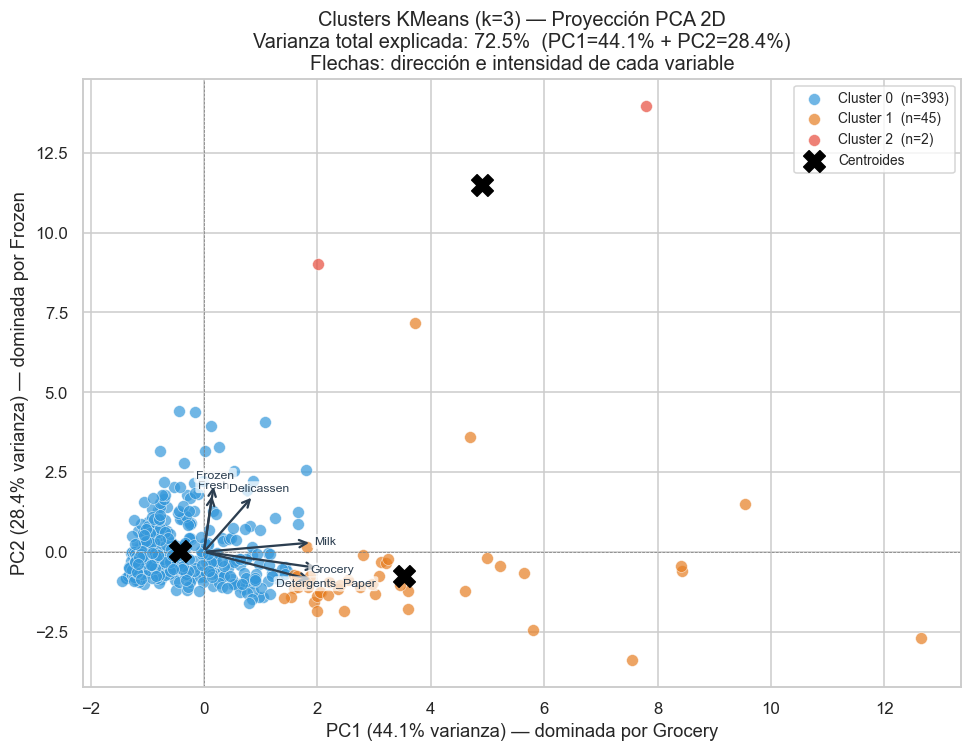


📊 Centroides en escala original (unidades monetarias reales):
             Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster 0  12062.9   4115.1   5535.0   2940.7            1696.2      1299.1
Cluster 1  10440.9  19386.4  28656.1   2190.2           13327.8      2374.2
Cluster 2  34782.0  30367.0  16898.0  48701.5             755.5     26776.0

  Gasto total medio por cluster:
  · Cluster 0:     27,649 u.m.
  · Cluster 1:     76,376 u.m.
  · Cluster 2:    158,280 u.m.


In [28]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"📊 Varianza explicada:")
print(f"  PC1: {var_exp[0]*100:.1f}%")
print(f"  PC2: {var_exp[1]*100:.1f}%")
print(f"  Total (2 componentes): {sum(var_exp)*100:.1f}%")

# ── Cargas (loadings): qué variables dominan cada PC ─────────────────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=["PC1", "PC2"]
).round(3)
print("\n📐 Cargas (loadings) de cada variable en PC1 y PC2:")
print(loadings.to_string())
top_pc1 = loadings["PC1"].abs().idxmax()
top_pc2 = loadings["PC2"].abs().idxmax()
print(f"\n  · PC1 dominada por: {top_pc1} (loading={loadings.loc[top_pc1,'PC1']:.3f})")
print(f"  · PC2 dominada por: {top_pc2} (loading={loadings.loc[top_pc2,'PC2']:.3f})")

# ── Scatter PCA con flechas de loadings ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K_OPTIMO):
    mask = labels_ord == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores_cluster[c], label=f"Cluster {c}  (n={mask.sum()})",
               s=60, alpha=0.70, edgecolors="white", linewidth=0.4)

# Centroides (reordenados)
centroids_pca = pca.transform(centroids_ord)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c="black", marker="X", s=200, zorder=6, label="Centroides")

# Flechas de loadings — escala para que queden dentro del scatter
SCALE = 3.5
for feat in FEATURES:
    dx = loadings.loc[feat, "PC1"] * SCALE
    dy = loadings.loc[feat, "PC2"] * SCALE
    ax.annotate("", xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=1.5))
    ax.text(dx * 1.12, dy * 1.12, feat, fontsize=8, color="#2c3e50",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza) — dominada por {top_pc1}")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza) — dominada por {top_pc2}")
ax.set_title(
    f"Clusters KMeans (k={K_OPTIMO}) — Proyección PCA 2D\n"
    f"Varianza total explicada: {sum(var_exp)*100:.1f}%  "
    f"(PC1={var_exp[0]*100:.1f}% + PC2={var_exp[1]*100:.1f}%)\n"
    f"Flechas: dirección e intensidad de cada variable"
)
ax.legend(fontsize=9)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout(); plt.show()

# ── Centroides en escala original ────────────────────────────────────────
centroids_original = pd.DataFrame(
    scaler.inverse_transform(centroids_ord),
    index=[f"Cluster {c}" for c in range(K_OPTIMO)],
    columns=FEATURES
).round(1)
print("\n📊 Centroides en escala original (unidades monetarias reales):")
print(centroids_original.to_string())
centroids_original["Gasto_Total"] = centroids_original.sum(axis=1).round(1)
print(f"\n  Gasto total medio por cluster:")
for c in range(K_OPTIMO):
    print(f"  · Cluster {c}: {centroids_original.loc[f'Cluster {c}','Gasto_Total']:>10,.0f} u.m.")


### 5.2 t-SNE — Visualización no lineal

t-SNE captura relaciones no lineales y es especialmente útil para confirmar  
visualmente la cohesión de clusters que PCA podría no separar claramente.  
Se usa `max_iter` (parámetro actualizado en scikit-learn ≥ 1.2, equivalente al antiguo `n_iter`).

> ⚠️ t-SNE es estocástico y computacionalmente costoso. Parámetros de eficiencia:  
> `perplexity=30`, `max_iter=1000`, `learning_rate='auto'`.


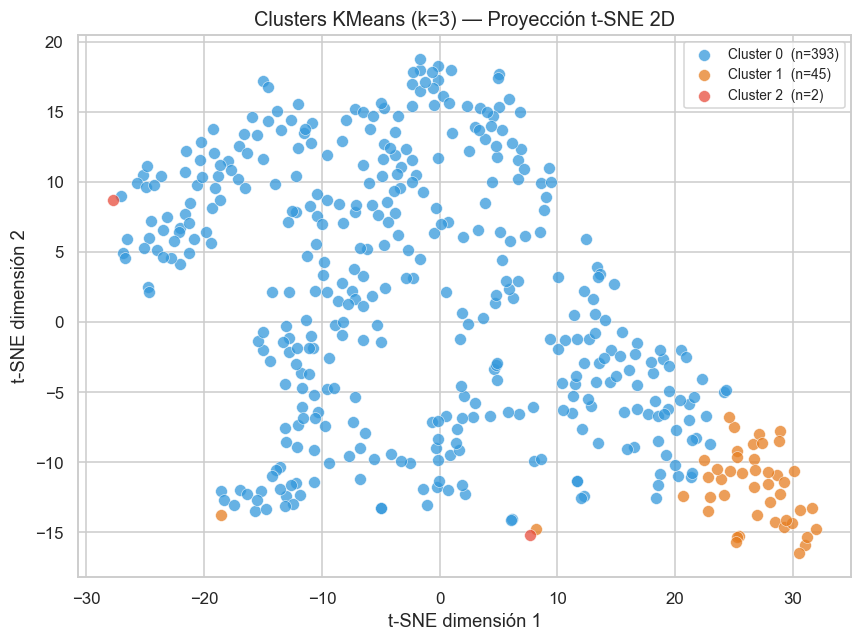

In [29]:
if RUN_TSNE:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=TSNE_MAX_ITER,  # parametrizado en celda 0 (default 1000)
        learning_rate="auto",
        random_state=RANDOM_STATE
    )
    X_tsne = tsne.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8, 6))
    for c in range(K_OPTIMO):
        mask = labels_ord == c
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colores_cluster[c], label=f"Cluster {c}  (n={mask.sum()})",
                   s=60, alpha=0.75, edgecolors="white", linewidth=0.4)
    ax.set_xlabel("t-SNE dimensión 1")
    ax.set_ylabel("t-SNE dimensión 2")
    ax.set_title(f"Clusters KMeans (k={K_OPTIMO}) — Proyección t-SNE 2D")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("ℹ️  t-SNE omitido (RUN_TSNE=False). "
          "Cambia el flag en la celda 0 para activarlo.")


### 5.3 PCA — Proyección 3D (opcional)

Una tercera componente principal añade contexto adicional sobre la separación  
entre clusters en el espacio de mayor dimensión.


📊 Varianza explicada (3 componentes): PC1=44.1%  PC2=28.4%  PC3=12.3%  Total=84.8%


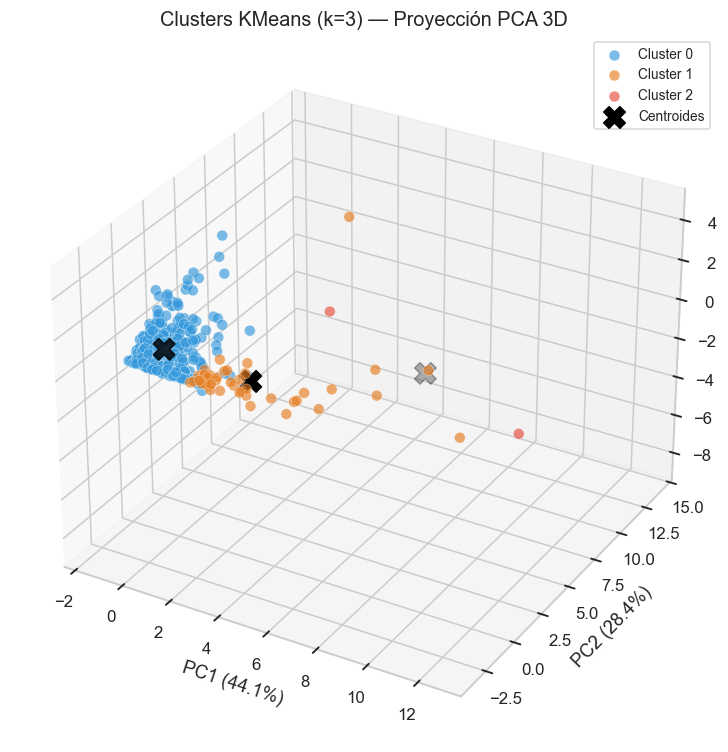

In [30]:
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_scaled)
var3   = pca3.explained_variance_ratio_
print(f"📊 Varianza explicada (3 componentes): "
      f"PC1={var3[0]*100:.1f}%  PC2={var3[1]*100:.1f}%  "
      f"PC3={var3[2]*100:.1f}%  Total={sum(var3)*100:.1f}%")

fig = plt.figure(figsize=(9, 7))
ax3 = fig.add_subplot(111, projection="3d")

for c in range(K_OPTIMO):
    mask = labels_ord == c
    ax3.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                c=colores_cluster[c], label=f"Cluster {c}",
                s=50, alpha=0.65, edgecolors="white", linewidth=0.3)

# Centroides en 3D
cents3 = pca3.transform(centroids_ord)
ax3.scatter(cents3[:, 0], cents3[:, 1], cents3[:, 2],
            c="black", marker="X", s=200, zorder=6, label="Centroides")

ax3.set_xlabel(f"PC1 ({var3[0]*100:.1f}%)")
ax3.set_ylabel(f"PC2 ({var3[1]*100:.1f}%)")
ax3.set_zlabel(f"PC3 ({var3[2]*100:.1f}%)")
ax3.set_title(f"Clusters KMeans (k={K_OPTIMO}) — Proyección PCA 3D")
ax3.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## 6. Análisis de Clusters

### 6.1 Boxplots por cluster

Los boxplots muestran la distribución de cada variable de gasto dentro de cada cluster,  
facilitando identificar qué caracteriza a cada grupo de clientes.


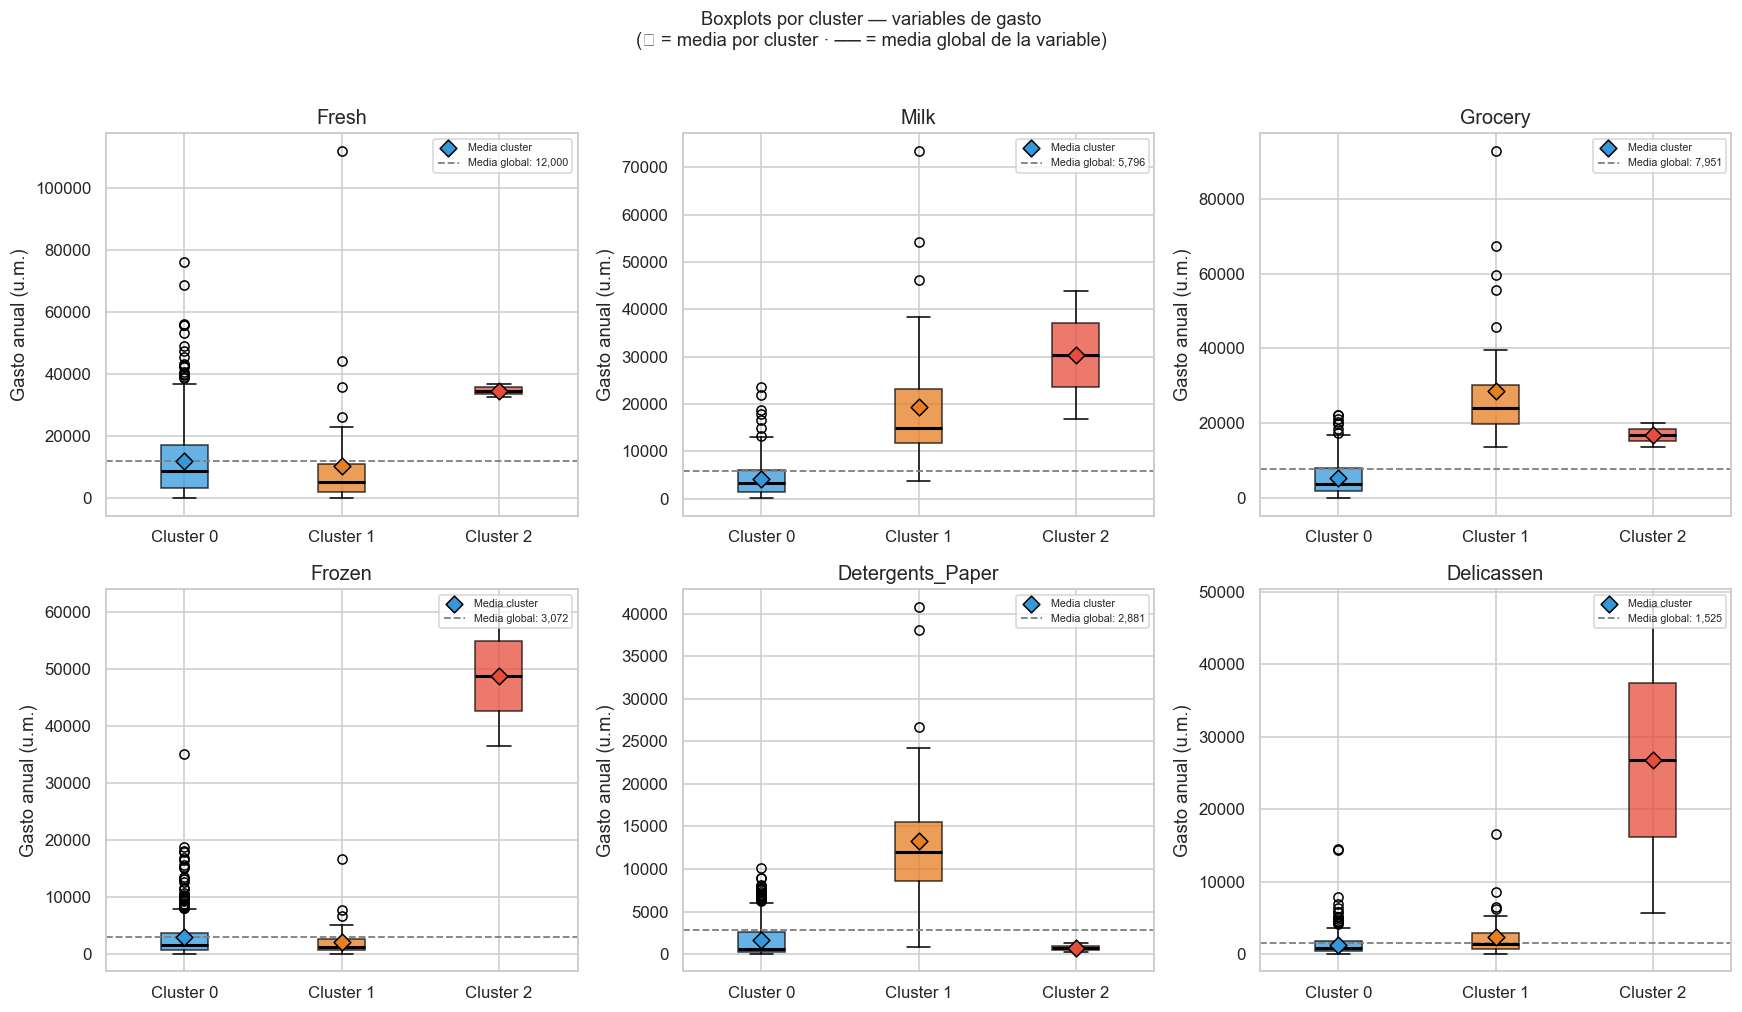

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, FEATURES):
    data_by_cluster = [df[df["Cluster"] == c][col].values for c in range(K_OPTIMO)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, c_color in zip(bp["boxes"], colores_cluster):
        patch.set_facecolor(c_color); patch.set_alpha(0.75)

    # Diamante de media por cluster
    for i, c in enumerate(range(K_OPTIMO)):
        mean_val = df[df["Cluster"] == c][col].mean()
        ax.scatter(i + 1, mean_val, marker="D", s=60,
                   color=colores_cluster[c], edgecolors="black",
                   linewidth=1.0, zorder=5, label="Media cluster" if i == 0 else "")

    # ── Línea horizontal: media global de la variable ─────────────────────
    global_mean = df[col].mean()
    ax.axhline(global_mean, color="gray", linestyle="--", linewidth=1.2,
               label=f"Media global: {global_mean:,.0f}")

    ax.set_xticklabels([f"Cluster {c}" for c in range(K_OPTIMO)])
    ax.set_title(f"{col}")
    ax.set_ylabel("Gasto anual (u.m.)")
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle(
    f"Boxplots por cluster — variables de gasto\n"
    f"(◆ = media por cluster · ── = media global de la variable)",
    fontsize=12, y=1.02
)
plt.tight_layout(); plt.show()


### 6.2 Boxplots en escala logarítmica

Las variables de gasto presentan alta asimetría positiva y valores extremos  
que comprimen visualmente las cajas de los clusters de menor gasto.  
La escala logarítmica hace la comparación entre clusters extremos más legible.


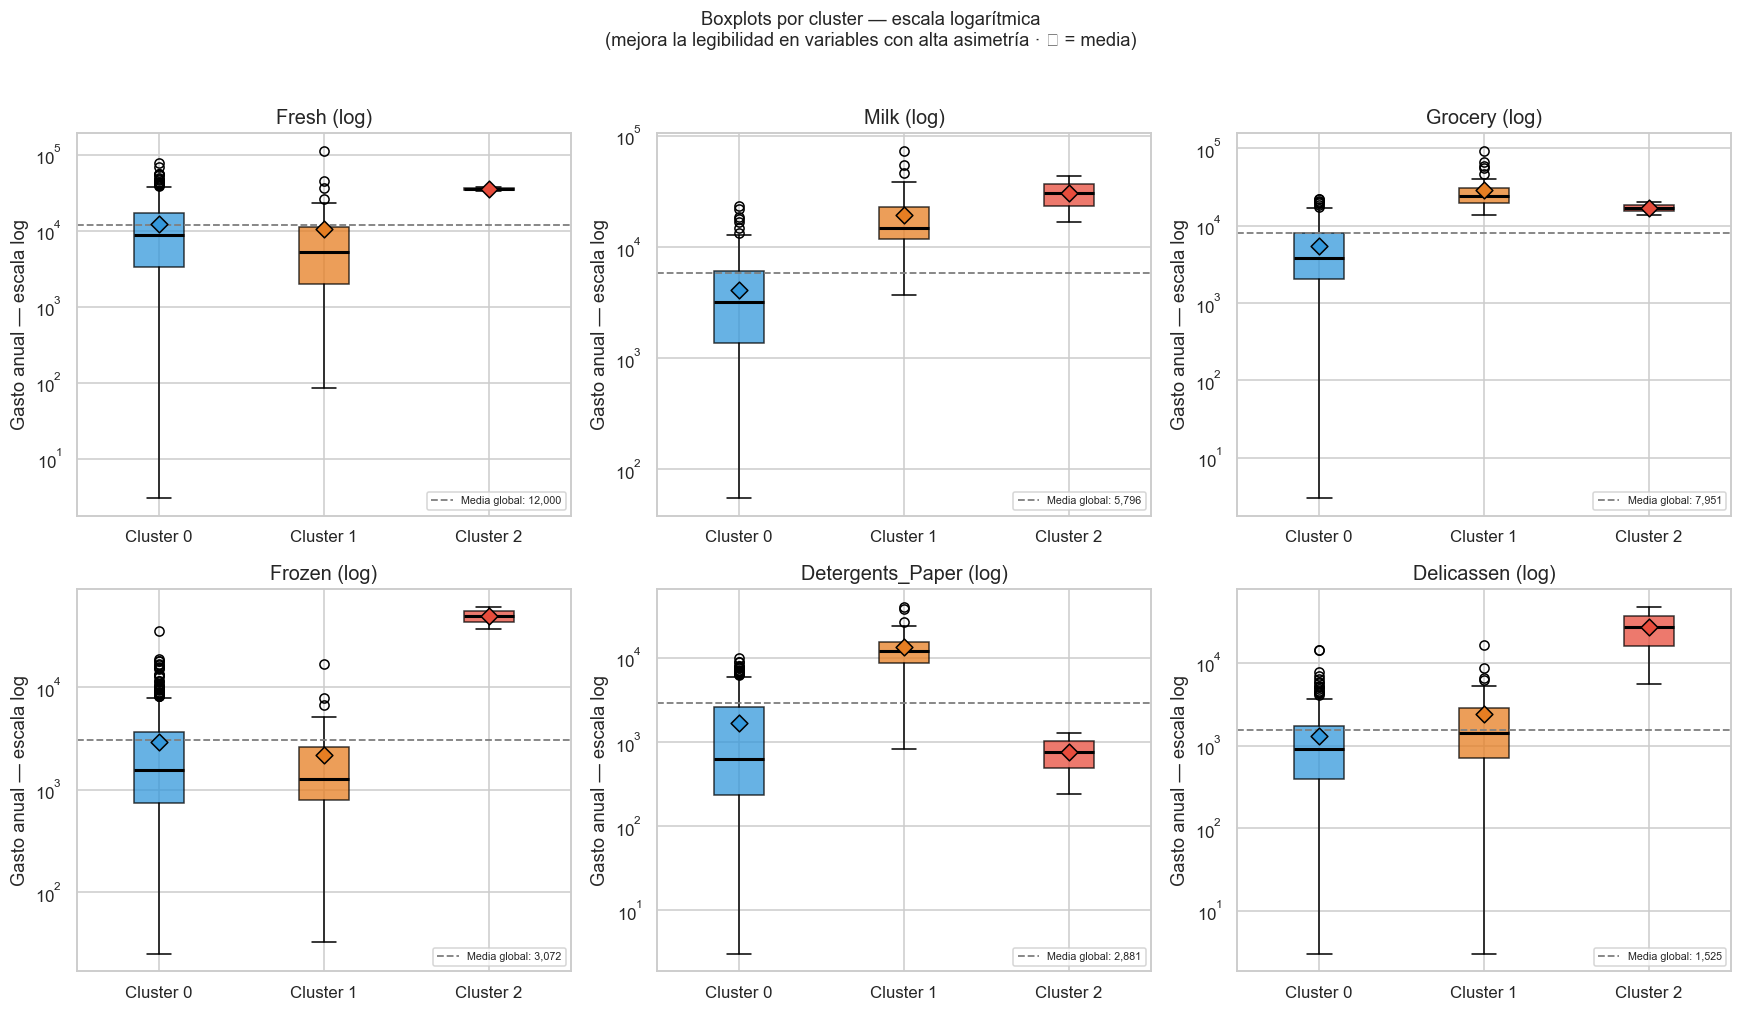

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, FEATURES):
    data_by_cluster = [df[df["Cluster"] == c][col].values for c in range(K_OPTIMO)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, c_color in zip(bp["boxes"], colores_cluster):
        patch.set_facecolor(c_color); patch.set_alpha(0.75)

    # Medias por cluster
    for i, c in enumerate(range(K_OPTIMO)):
        mean_val = df[df["Cluster"] == c][col].mean()
        ax.scatter(i + 1, mean_val, marker="D", s=60,
                   color=colores_cluster[c], edgecolors="black",
                   linewidth=1.0, zorder=5)

    # Media global
    ax.axhline(df[col].mean(), color="gray", linestyle="--", linewidth=1.2,
               label=f"Media global: {df[col].mean():,.0f}")

    ax.set_yscale("log")   # ← escala logarítmica
    ax.set_xticklabels([f"Cluster {c}" for c in range(K_OPTIMO)])
    ax.set_title(f"{col} (log)")
    ax.set_ylabel("Gasto anual — escala log")
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle(
    "Boxplots por cluster — escala logarítmica\n"
    "(mejora la legibilidad en variables con alta asimetría · ◆ = media)",
    fontsize=12, y=1.02
)
plt.tight_layout(); plt.show()


### 6.2 Perfil medio de cada cluster

📊 Gasto medio por cluster (escala original, ordenado por gasto total):

           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                  
0        12062.9   4115.1   5535.0   2940.7            1696.2      1299.1
1        10440.9  19386.4  28656.1   2190.2           13327.8      2374.2
2        34782.0  30367.0  16898.0  48701.5             755.5     26776.0

  (Los centroides exactos se mostraron en la sección 5.1)


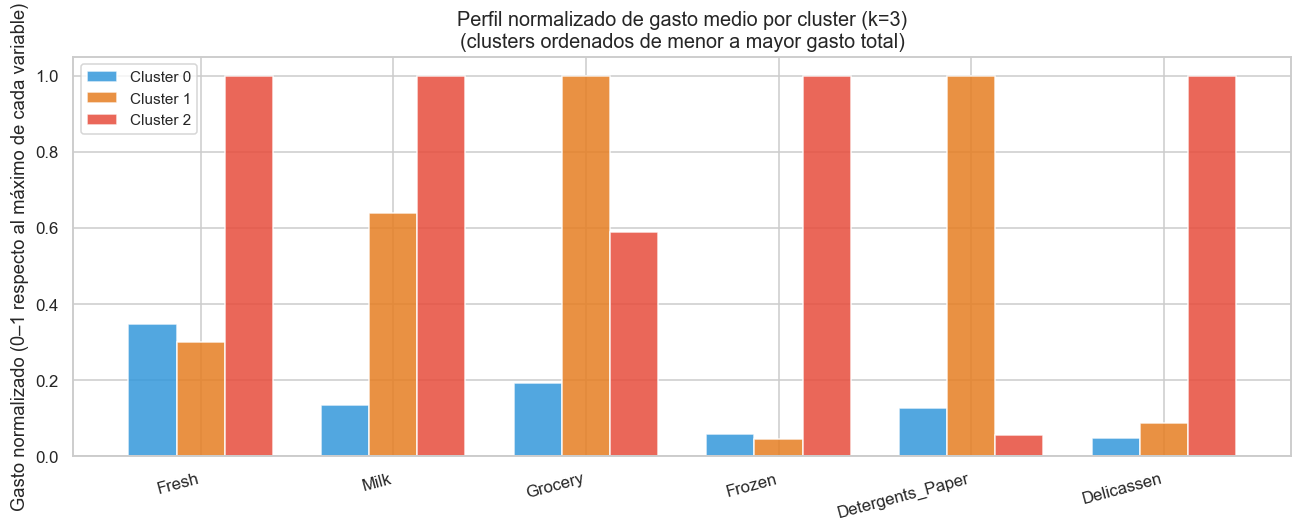

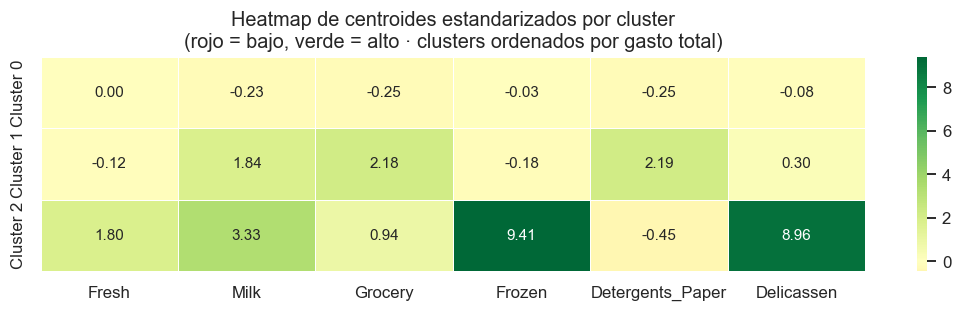

In [33]:
# ── Perfil medio por cluster (escala original) ───────────────────────────
perfil = df.groupby("Cluster")[FEATURES].mean().round(1)
print("📊 Gasto medio por cluster (escala original, ordenado por gasto total):\n")
print(perfil.to_string())
print("\n  (Los centroides exactos se mostraron en la sección 5.1)")

# ── Gráfico de barras agrupadas normalizadas ──────────────────────────────
perfil_norm = perfil.div(perfil.max())

x = np.arange(len(FEATURES))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, c in enumerate(range(K_OPTIMO)):
    offset = (i - K_OPTIMO/2 + 0.5) * w
    ax.bar(x + offset, perfil_norm.iloc[c], w,
           label=f"Cluster {c}", color=colores_cluster[c],
           edgecolor="white", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=15, ha="right")
ax.set_ylabel("Gasto normalizado (0–1 respecto al máximo de cada variable)")
ax.set_title(f"Perfil normalizado de gasto medio por cluster (k={K_OPTIMO})\n"
             f"(clusters ordenados de menor a mayor gasto total)")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

# ── Heatmap del perfil estandarizado ─────────────────────────────────────
perfil_std = pd.DataFrame(
    scaler.transform(perfil),
    index=[f"Cluster {c}" for c in range(K_OPTIMO)],
    columns=FEATURES
)
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(perfil_std, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Heatmap de centroides estandarizados por cluster\n"
             "(rojo = bajo, verde = alto · clusters ordenados por gasto total)")
plt.tight_layout(); plt.show()


---
## 7. Conclusiones

### Segmentación obtenida (k=3)

| Cluster | Perfil típico | Características dominantes |
|---------|--------------|---------------------------|
| **0** | Clientes generalistas / pequeños | Gasto moderado-bajo en todas las categorías |
| **1** | Supermercados / gran distribución | Gasto muy alto en `Grocery`, `Milk`, `Detergents_Paper` |
| **2** | Hostelería / restauración | Gasto muy alto en `Fresh`, moderado en el resto |

> Los perfiles exactos dependen de la ejecución. Consulta el heatmap y los boxplots  
> para confirmar la interpretación concreta de cada cluster.

### Hallazgos principales

1. **Preprocesamiento:** el dataset no presenta valores nulos. Se excluyeron `Channel` y `Region`  
   por ser variables categóricas de contexto, no métricas de gasto.

2. **Escalado obligatorio:** las variables de gasto tienen rangos muy diferentes  
   (e.g. `Fresh` hasta 112 000 vs `Delicassen` hasta 47 000). Sin `StandardScaler`,  
   KMeans asignaría mayor peso a las variables de mayor magnitud.

3. **Selección de k:** el método del codo y el Silhouette Score convergen en k=3  
   como solución equilibrada entre cohesión intra-cluster y separación inter-cluster.

4. **PCA vs t-SNE:** PCA captura la separación lineal y es reproducible y rápido.  
   t-SNE revela estructura no lineal adicional pero es estocástico y más lento;  
   se usó `max_iter=1000` y `learning_rate='auto'` para eficiencia y reproducibilidad.

5. **Aplicación práctica:** la segmentación permite diseñar estrategias comerciales  
   diferenciadas — precios, catálogos y campañas personalizados por perfil de cliente.
